# Polygon coverage explorer

In this notebook you will see how to:

- use Polytope to retrieve a country cut-out of Portugal
- create a point cloud plot of the retrieved fields

### Components of earthkit

This tutorial uses the following earthkit components - click any logo to open the package documentation:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-geo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-geo-light.svg" alt="earthkit-geo" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a> 
</div>

### 1. Data extraction

We generate the country polygon for Portugal using earthkit-geo, then retrieve data within that polygon with Polytope and convert to xarray.

In [1]:
import earthkit.data as ekd
from earthkit.geo.cartography import country_polygons

coords = country_polygons("Portugal")

request = {
    "class": "od",
    "stream": "enfo",
    "type": "pf",
    "date": -1,
    "time": "1200",
    "levtype": "sfc",
    "expver": 1,
    "domain": "g",
    "param": "167/169",
    "number": "1",
    "step": "0",
    "feature": {"type": "polygon", "shape": coords},
}

ds = ekd.from_source(
    "polytope", "ecmwf-mars", request, stream=False, address="polytope.ecmwf.int"
).to_xarray()
ds

<xarray.Dataset> Size: 54kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 1118)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2026-04-14T12:00:00Z'
  * number     (number) int64 8B 1
  * steps      (steps) int64 8B 0
  * points     (points) int64 9kB 0 1 2 3 4 5 ... 1112 1113 1114 1115 1116 1117
    latitude   (points) float64 9kB 36.87 36.87 36.94 ... 42.14 42.21 42.21
    longitude  (points) float64 9kB 352.1 352.2 351.2 ... 351.7 351.6 351.7
    levelist   (points) float64 9kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    2t         (datetimes, number, steps, points) float64 9kB 288.4 ... 284.7
    ssrd       (datetimes, number, steps, points) float64 9kB 0.0 0.0 ... 0.0
Attributes:
    class:          od
    Forecast date:  2026-04-14T12:00:00Z
    domain:         g
    expver:         0001
    levtype:        sfc
    number:         1
    step:           0
    stream:         enfo
    type:           pf
    date:           2026-04-14T12:00:00Z

### 2. Plot the extracted data 

The data can then be easily plotted as a point cloud using earthkit-plots.

axis='', name='points', long_name='', standard_name='', units

<xarray.DataArray 'points' (points: 1118)> Size: 9kB
array([   0,    1,    2, ..., 1115, 1116, 1117], shape=(1118,))
Coordinates:
    datetimes  <U20 80B '2026-04-14T12:00:00Z'
    number     int64 8B 1
    steps      int64 8B 0
  * points     (points) int64 9kB 0 1 2 3 4 5 ... 1112 1113 1114 1115 1116 1117
    latitude   (points) float64 9kB 36.87 36.87 36.94 ... 42.14 42.21 42.21
    longitude  (points) float64 9kB 352.1 352.2 351.2 ... 351.7 351.6 351.7
    levelist   (points) float64 9kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

<class 'numpy.ndarray'> (1118,)
axis='', name='points', long_name='', standard_name='', units

<xarray.DataArray 'points' (points: 1118)> Size: 9kB
array([   0,    1,    2, ..., 1115, 1116, 1117], shape=(1118,))
Coordinates:
    datetimes  <U20 80B '2026-04-14T12:00:00Z'
    number     int64 8B 1
    steps      int64 8B 0
  * points     (points) int64 9kB 0 1 2 3 4 5 ... 1112 1113 1114 1115 1

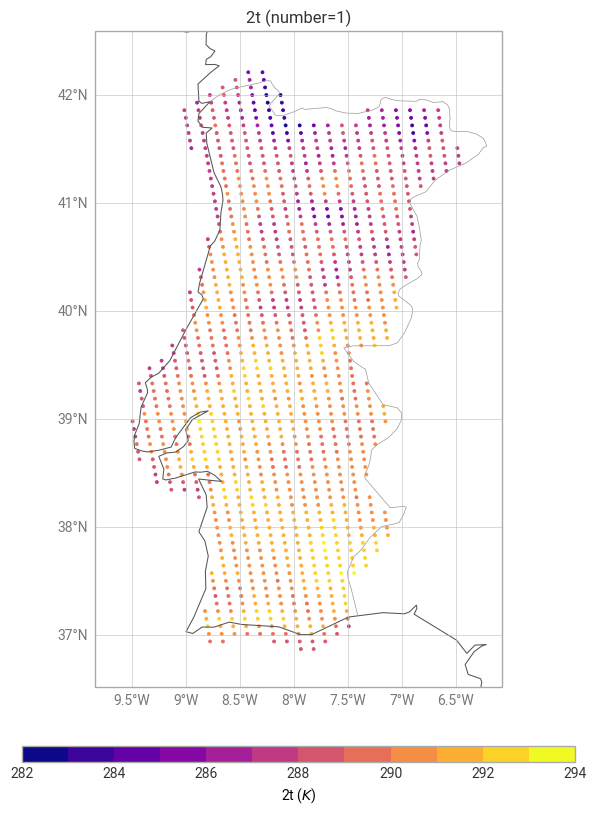

In [2]:
import earthkit.plots as ekp

chart = ekp.Map(domain="Portugal")
chart.point_cloud(ds["2t"])

chart.coastlines()
chart.borders()
chart.gridlines()

chart.title("{variable_name} (number={number})")

chart.legend()

chart.show()